# Testing
### Bevölkerung nach Religion, seit 1850

Beschreibung
Diese Daten beschreiben die ständige Wohnbevölkerung der Stadt Zürich und basieren auf der Volkszählung und der Strukturerhebung des Bundesamts für Statistik.

Bei der Volkszählung sind Personen aller Altersjahre enthalten, bei der Strukturerhebung bloss 15-Jährige und Ältere. Weitere Informationen finden Sie unter Bemerkung.

Datum: 27.02.2026


Dataset auf PROD-Datakatalog: Link https://data.stadt-zuerich.ch/dataset/bfs_ste_bev_religion_seit1850_od3150

Dataset auf INTEG-Datakatalog: Link https://data.integ.stadt-zuerich.ch/dataset/int_dwh_bfs_ste_bev_religion_seit1850_od3150

### Importiere die notwendigen Packages

In [40]:
#%pip install geopandas altair fiona requests folium mplleaflet contextily seaborn datetime plotly leafmap

In [41]:
import altair as alt
import datetime
import folium 
import geopandas as gpd
import io
from IPython.display import Markdown as md
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
#import pivottablejs
#from pivottablejs import pivot_ui
import plotly.express as px
import requests
import seaborn as sns

Welche Python, Altair und Seaborn Version wird verwendet?

In [42]:
#base env 2025: Python 3.11.7
import ipykernel
print(ipykernel.__version__)

import sys
import platform
print("Python-Version:", sys.version)
print("Python-Implementierung:", platform.python_implementation())
print("Python-Build:", platform.python_build())
print("Python-Compiler:", platform.python_compiler())

print("Altair-Version:", alt.__version__)
print("Seaborn-Version:", sns.__version__)

6.29.3
Python-Version: 3.11.8 | packaged by Anaconda, Inc. | (main, Feb 26 2024, 21:34:05) [MSC v.1916 64 bit (AMD64)]
Python-Implementierung: CPython
Python-Build: ('main', 'Feb 26 2024 21:34:05')
Python-Compiler: MSC v.1916 64 bit (AMD64)
Altair-Version: 5.0.1
Seaborn-Version: 0.12.2


Importiere die eigenen Funktionen, die unter ../0_scripts abegelegt sind:

In [43]:
import sys
sys.path.append('../0_scripts')

import my_py_dataviz_functions as mypy_dv
import my_py_dataloading_functions as mypy_dl

In [44]:
SSL_VERIFY = False
# evtl. SSL_VERIFY auf False setzen wenn die Verbindung zu https://www.gemeinderat-zuerich.ch nicht klappt (z.B. wegen Proxy)
# Um die SSL Verifikation auszustellen, bitte die nächste Zeile einkommentieren ("#" entfernen)
# SSL_VERIFY = False

In [45]:
if not SSL_VERIFY:
    import urllib3
    urllib3.disable_warnings()

### Settings
Definiere Settings. 
Hier das Zahlenformat von Float-Werten (z.B. *'{:,.2f}'.format* mit Komma als Tausenderzeichen)

In [46]:
#pd.options.display.float_format = lambda x : '{:,.1f}'.format(x) if (np.isnan(x) | np.isinf(x)) else '{:,.0f}'.format(x) if int(x) == x else '{:,.1f}'.format(x)
pd.options.display.float_format = '{:.0f}'.format
pd.set_option('display.width', 100)
pd.set_option('display.max_columns', 15)

#### Paletten aus Zuericolors
Die Farbwerte habe ich aus R ausgelesen. Siehe dazu: `G:\sszsim\myR\zuericolors4python`

In [47]:
# Quantitative Paletten
zuericolors_qual12 = ["#3431DE", "#0A8DF6", "#23C3F1", "#7B4FB7", "#DB247D", "#FB737E", "#007C78", "#1F9E31", "#99C32E", "#9A5B01", "#FF720C", "#FBB900"]
zuericolors_qual12br = ["#5D4BFE", "#4AA9FF", "#55FFFF", "#986AD5", "#FC4C99", "#FF919A", "#349894", "#44B14A", "#B7E14E", "#B97624", "#FF7231", "#FFD736"]
zuericolors_qual12da= ["#0017BF", "#0072D7", "#00A5D2", "#5E359A", "#BA0062", "#DA5563", "#00615D", "#00770F", "#7BA600", "#7B4100", "#DC5500", "#DA9C00"]
# Divergente Paletten
zuericolors_div9val  =  ["#A30059", "#DB247D", "#FF579E", "#FFA8D0", "#E4E0DF", "#A8DBB1", "#55BC5D", "#1F9E31", "#10652A"] 
zuericolors_div9ntr  =  ["#782600", "#CC4309", "#FF720C", "#FFBC88", "#E4E0DF", "#AECBFF", "#6B8EFF", "#3B51FF", "#2F2ABB"] 
# Geschlechter Paletten
zuericolors_gender3  =  ["#349894", "#FFD736", "#986AD5"] 
zuericolors_gender6origin  =  ["#00615D", "#349894", "#DA9C00", "#FFD736", "#5E359A", "#986AD5"] 
zuericolors_gender5wedding  =  ["#349894", "#FFD736", "#3431DE", "#B8B8B8", "#D6D6D6"] 
# Sequenzielle Paletten
zuericolors_seq9blu  =  ["#CADEFF", "#AEC2FF", "#93A6FF", "#778AFF", "#5B6EFF", "#4D59E2", "#3E44C5", "#302FA7", "#211A8A"] 
zuericolors_seq9red  =  ["#FED2EE", "#FEAED6", "#F589BE", "#F165A5", "#ED408D", "#D1307B", "#B52069", "#991056", "#7D0044"] 
zuericolors_seq9grn  =  ["#CFEED8", "#A8E0B3", "#81D18F", "#5BC36A", "#34B446", "#2A9A3C", "#208032", "#166529", "#0C4B1F"] 
zuericolors_seq9brn  =  ["#FCDDBB", "#F7BD8C", "#F39D5E", "#EE7D2F", "#EA5D00", "#C84E00", "#A53E00", "#832F00", "#611F00"]

#### Zeitvariabeln


In [48]:
#Zeitvariabeln als Strings:
now = datetime.date.today()
year_today = now.strftime("%Y")
date_today = "_"+now.strftime("%Y-%m-%d")

#Zeitvariabeln als Integers:
int_times = now.timetuple()
aktuellesJahr = int_times[0]
aktuellerMonat = int_times[1]
selectedMonat = int_times[1]-2
#print(aktuellesJahr, aktuellerMonat,'datenstand: ', selectedMonat, int_times)

### Daten importieren und Metadaten checken

- status: int / prod
- data_source: web / ld / dropzone
- datums_attr: beschreibt das oder die Datumsfelder, die als Datum geparsed werden sollen. Falls es keines gibt: None

In [49]:
package_name = "bfs_ste_bev_religion_seit1850_od3150"

In [50]:
data2betested = mypy_dl.load_data(
    status = 'int'
    , data_source = 'web'
    , package_name = package_name
    , dataset_name = "BEV315OD3150"    
    , datums_attr = ["Jahr"]
    )

fp lautet:https://data.integ.stadt-zuerich.ch/dataset/int_dwh_bfs_ste_bev_religion_seit1850_od3150/download/BEV315OD3150.csv


 **Überprüfe die Metadaten:**

 **Dataset auf INTEG-Datakatalog:** Link https://data.integ.stadt-zuerich.ch/dataset/int_dwh_bfs_ste_bev_religion_seit1850_od3150 

 **Dataset auf PROD-Datakatalog:** Link https://data.stadt-zuerich.ch/dataset/bfs_ste_bev_religion_seit1850_od3150 

data_source: web


In [51]:
data2betested.head(2).T

,0,1
Jahr,1970-01-01 00:00:00,1980-01-01 00:00:00
Religion,Ohne Religionszugehörigkeit,Ohne Religionszugehörigkeit
AntBev,2,6
untAntBevKI,NaN,NaN
obAntBevKI,NaN,NaN


Berechne weitere Attribute falls notwendig

In [52]:
data2betested = (
    data2betested
    .copy()
    .assign(
        #Aktualisierungs_Datum_str= lambda x: x.Aktualisierungs_Datum.astype(str),
        Jahr_str = lambda x: x.Jahr.astype(str)
    )
    .sort_values('Jahr', ascending=False)
    )
data2betested.dtypes

Jahr           datetime64[ns]
Religion               object
AntBev                float64
untAntBevKI           float64
obAntBevKI            float64
Jahr_str               object
dtype: object

Minimales und maximales Jahr im Datensatz

In [53]:
data_max_jahr = str(max(data2betested.Jahr).year)
data_min_jahr = str(min(data2betested.Jahr).year)

print(f"Die Daten haben ein Minimumjahr von {data_min_jahr} und ein Maximumjahr von {data_max_jahr}")

Die Daten haben ein Minimumjahr von 1850 und ein Maximumjahr von 2024


### Einfache Datentests

In [54]:
data2betested.info(memory_usage='deep', verbose=True)

<class 'pandas.core.frame.DataFrame'>
Index: 148 entries, 147 to 50
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   Jahr         148 non-null    datetime64[ns]
 1   Religion     148 non-null    object        
 2   AntBev       148 non-null    float64       
 3   untAntBevKI  83 non-null     float64       
 4   obAntBevKI   83 non-null     float64       
 5   Jahr_str     148 non-null    object        
dtypes: datetime64[ns](1), float64(3), object(2)
memory usage: 28.5 KB


In [55]:
print(f'The dataset has {data2betested.shape[0]:,.0f} rows (observations) and {data2betested.shape[1]:,.0f} columns (variables).')
print(f'There seem to be {data2betested.duplicated().sum()} exact duplicates in the data.')

The dataset has 148 rows (observations) and 6 columns (variables).
There seem to be 0 exact duplicates in the data.


Beschreibe einzelne Attribute

In [56]:
data2betested.describe()

,Jahr,AntBev,untAntBevKI,obAntBevKI
count,148,148,83,83
mean,1982-02-11 20:55:08.108108096,20,16,17
min,1850-01-01 00:00:00,0,0,0
25%,1957-07-02 00:00:00,1,1,2
50%,2011-01-01 00:00:00,16,17,18
75%,2018-01-01 00:00:00,30,27,28
max,2024-01-01 00:00:00,93,49,51
std,NaN,22,14,15


Welches sind die irgendwo keine Werte bei BEW?

In [57]:
data2betested[np.isnan(data2betested.AntBev)]

,Jahr,Religion,AntBev,untAntBevKI,obAntBevKI,Jahr_str


### Verwende das Datum als Index

While we did already parse the `datetime` column into the respective datetime type, it currently is just a regular column. 
**To enable quick and convenient queries and aggregations, we need to turn it into the index of the DataFrame**

In [58]:
data2betested = data2betested.set_index("Jahr")
data2betested = data2betested.sort_index()

In [59]:
data2betested.index.year.unique()

Index([1850, 1860, 1870, 1880, 1888, 1900, 1910, 1920, 1930, 1940, 1950, 1960, 1970, 1980, 1990,
       2000, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023,
       2024],
      dtype='int32', name='Jahr')

### Beschreibe einzelne Attribute

Beschreibe nicht numerische Attribute

In [60]:
# describe non-numerical features
try:
    with pd.option_context('display.float_format', '{:,.2f}'.format):
        display(data2betested.describe(exclude='number')) #,datetime_is_numeric=True
except:
    print("No categorical data in dataset.")

,Religion,Jahr_str
count,148,148
unique,6,31
top,Evangelisch-reformiert,2000-01-01
freq,31,6


Beschreibe numerische Attribute

In [61]:
# describe numerical features
try:
    with pd.option_context('display.float_format', '{:,.0f}'.format):
        display(data2betested.describe(include='number'))
except:
    print("No numercial data in dataset.")

,AntBev,untAntBevKI,obAntBevKI
count,148,83,83
mean,20,16,17
std,22,14,15
min,0,0,0
25%,1,1,2
50%,16,17,18
75%,30,27,28
max,93,49,51


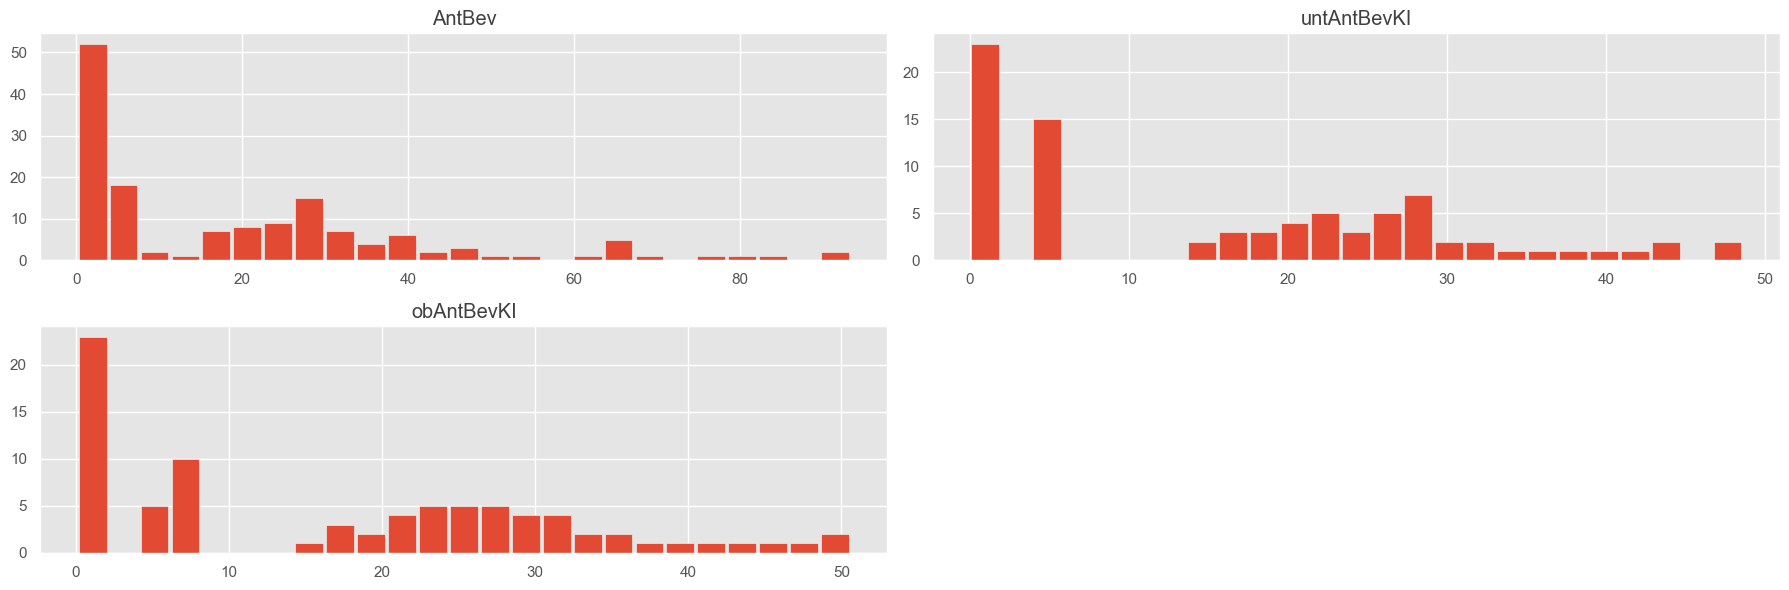

In [62]:
plt.style.use('ggplot')
params = {
    'text.color': (0.25, 0.25, 0.25),
    'figure.figsize': [18, 6],
   }
plt.rcParams.update(params)

try:
    data2betested.hist(bins=25, rwidth=0.9)
    plt.tight_layout()
    plt.show()
except:
    print("No numercial data to plot.") 

### Gibt es Duplikate?

In [63]:
# find duplicate rows
duplicate_rows = data2betested[data2betested.duplicated()]
duplicate_rows

,Religion,AntBev,untAntBevKI,obAntBevKI,Jahr_str
Jahr,,,,,


### Nullwerte und Missings?

In [64]:
data2betested.isnull().sum()

Religion        0
AntBev          0
untAntBevKI    65
obAntBevKI     65
Jahr_str        0
dtype: int64

In [65]:
# check missing values with missingno
# https://github.com/ResidentMario/missingno
#import missingno as msno
#msno.matrix(data2betested, labels=True, sort='descending');
#msno.heatmap(data2betested)

### Gruppierungen

In [66]:
data2betested.columns

Index(['Religion', 'AntBev', 'untAntBevKI', 'obAntBevKI', 'Jahr_str'], dtype='object')

### Pivotiere

In [67]:
pivoted_df = data2betested.pivot_table(
    index='Religion',
    columns= ('Jahr'),
    values=['AntBev', 'untAntBevKI', 'obAntBevKI'],
    aggfunc='sum'
)

# Sortieren nach der Aggregation 
pivoted_df = pivoted_df.sort_values(by=pivoted_df.index[-1], axis=1, ascending=False)

# Sortieren der Zeilen (Jahre) in absteigender Reihenfolge
#pivoted_df = pivoted_df.sort_index(ascending=True)

# Anzeigen des Ergebnisses
print(pivoted_df)

                                AntBev                                             obAntBevKI  \
Jahr                        1970-01-01 1980-01-01 1990-01-01 1960-01-01 2000-01-01 2010-01-01   
Religion                                                                                        
Christkatholisch                     0          0          0          1          0        NaN   
Evangelisch-reformiert              55         48         40         60         32         27   
Jüdisch                              1          1          1          1          1          1   
Muslimisch                           0          1          2        NaN          6          6   
Ohne Religionszugehörigkeit          2          6         10        NaN         17         28   
Römisch-katholisch                  40         39         39         36         33         31   

                                AntBev  ... untAntBevKI                                   \
Jahr                        1910-0

### Data Viz

#### Barcharts mit Seaborn

In [68]:
#myAgg = data2betested.loc["2008-11-30":"2021-10-31"]
myAggBar = data2betested

In [69]:
#help(sns.catplot)   

# #Stile for the following sns graphs
sns.set_theme(style="whitegrid")

In [70]:
data2betested.reset_index().columns

Index(['Jahr', 'Religion', 'AntBev', 'untAntBevKI', 'obAntBevKI', 'Jahr_str'], dtype='object')

##### Stacked Bar Chart

In [71]:
# Daten vorbereiten

data = data2betested.loc[data_max_jahr].reset_index()
data_pivoted = data.pivot(index='Religion', columns='Jahr', values='AntBev').fillna(0)
#Sortierung nach Maxwert
data_pivoted = data_pivoted.loc[
    data_pivoted.max(axis=1).sort_values(ascending=False).index
]

data_pivoted

Jahr,2024-01-01
Religion,
Ohne Religionszugehörigkeit,50
Römisch-katholisch,20
Evangelisch-reformiert,15
Muslimisch,6
Jüdisch,1
Christkatholisch,0


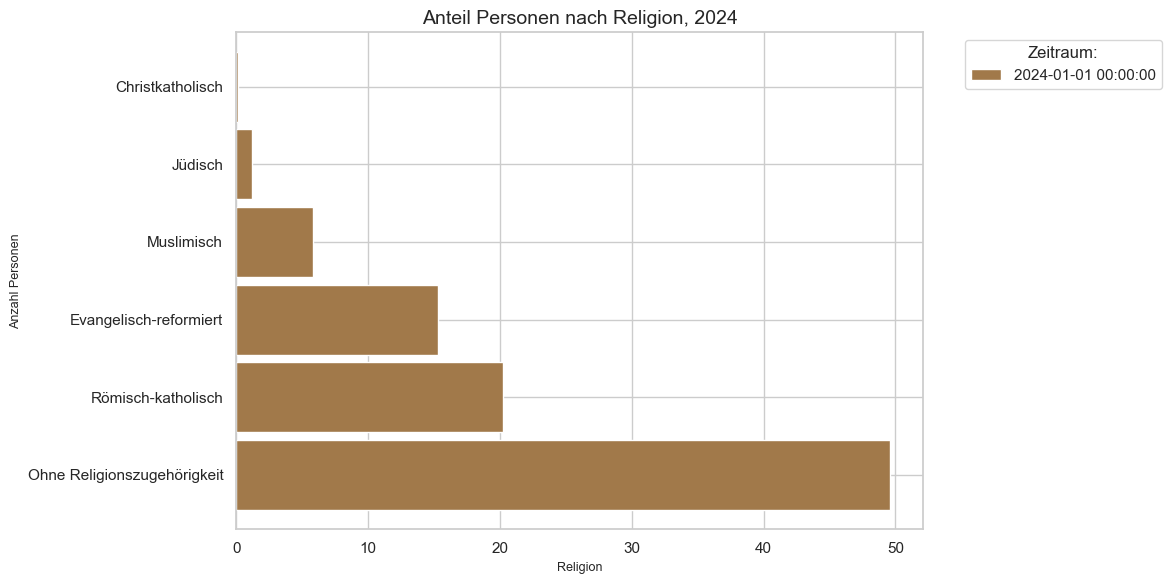

In [72]:
# Farbpalette erstellen
colors = sns.color_palette("cubehelix", n_colors=len(data_pivoted.columns)) #"flare" / "vlag" / "icefire" / "Spectral"
# Figur und Achsen erstellen
fig, ax = plt.subplots(figsize=(12, 6))
# Gestapeltes Balkendiagramm zeichnen
data_pivoted.plot(
    kind='barh', # barh für horizontale Balken, bar für vertikale Balken
    stacked=True, 
    ax=ax, 
    color=colors,
    width=0.9
    )
# Titel hinzufügen
plt.title('Anteil Personen nach Religion, ' + str(data_max_jahr), fontsize=14)
# Achsenbeschriftungen anpassen
ax.set_xlabel('Religion', fontsize=9)
ax.set_ylabel('Anzahl Personen', fontsize=9)

# Legende anpassen
plt.legend(title='Zeitraum:', bbox_to_anchor=(1.05, 1), loc='upper left')
# Layout anpassen
plt.tight_layout()
# Diagramm anzeigen
plt.show()

#### Faced Grids

In [73]:
data2betested.columns

Index(['Religion', 'AntBev', 'untAntBevKI', 'obAntBevKI', 'Jahr_str'], dtype='object')

In [74]:
# Um Warnings von Seaborn zu vermeiden, wenn die Daten NaN oder Inf Werte enthalten, können wir diese Werte durch NaN ersetzen. Das ermöglicht es Seaborn, die Daten korrekt zu verarbeiten und die Grafiken ohne Fehler zu erstellen.
data_clean = (
    data2betested
    .replace([np.inf, -np.inf], np.nan)
)

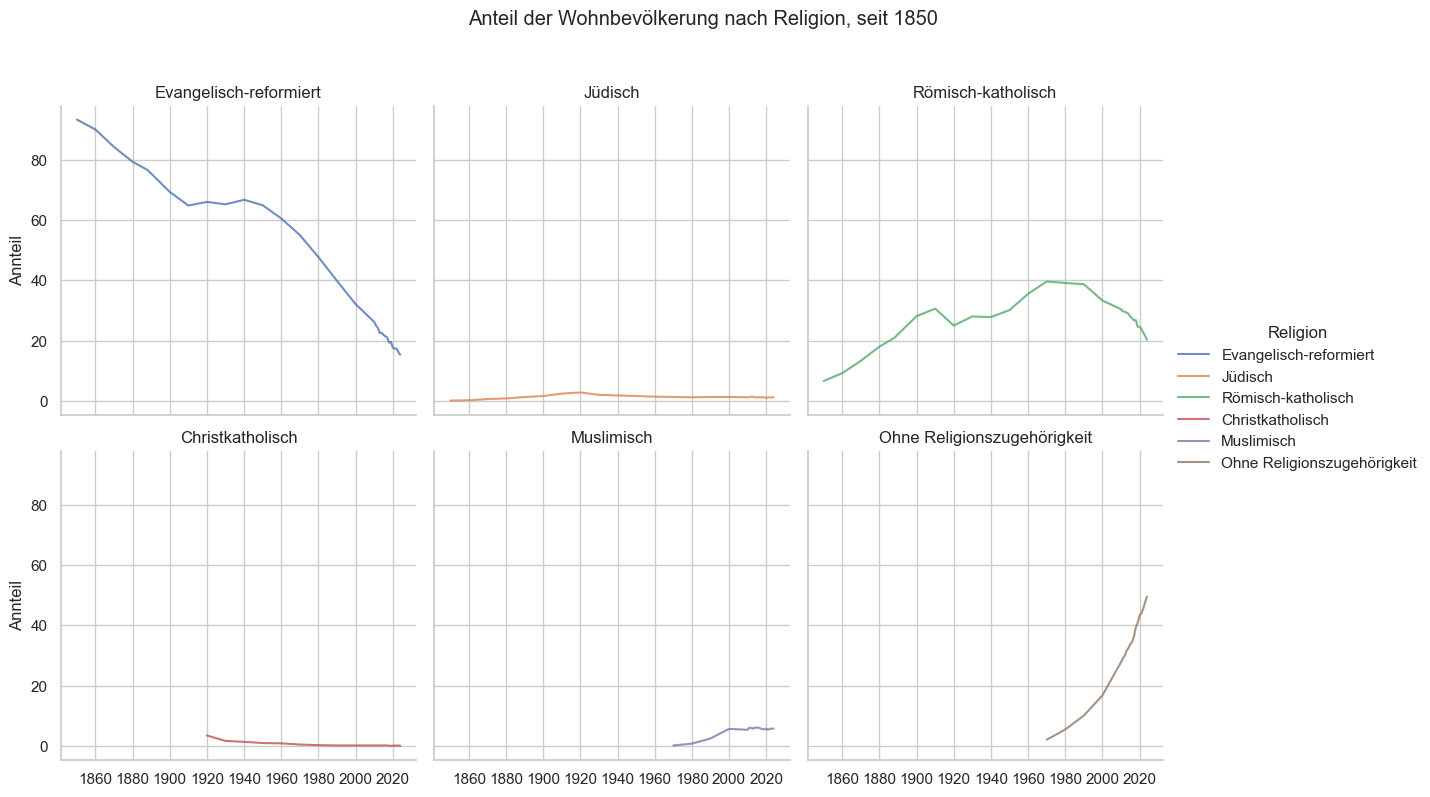

In [75]:
faced_grid1 = mypy_dv.plot_sns_facetgrid(
    data = data_clean.reset_index()
    ,col = "Religion"
    ,hue = "Religion"
    ,col_wrap = 3
    ,grafiktyp = sns.lineplot
    ,x = "Jahr"
    ,y = "AntBev"
    ,ylabel= "Annteil"
    ,warning_status ="ignore"
    ,height = 3
    ,myTitle="Anteil der Wohnbevölkerung nach Religion, seit "+str(int(data2betested.index.year.min()))
)
faced_grid1

#### Treemaps

**Funktion zum einfärben**

Muss ich noch als Funktion umsetzen 

In [76]:
# Extrahiere die Top-Fahrzeugmarken
auspraegungen = data2betested['Religion'].unique().tolist()
# Verfügbare Farben
verfügbare_farben_zuericolors = zuericolors_qual12da+zuericolors_qual12br+zuericolors_qual12+zuericolors_div9ntr

# Erstelle das Farben-Dictionary
farben_dict_zc = {'(?)':'lightgrey'}
for index, x in enumerate(auspraegungen):
    farben_dict_zc[x] = verfügbare_farben_zuericolors[index % len(verfügbare_farben_zuericolors)]

# Das resultierende Farben-Dictionary
print(farben_dict_zc)
#print(verfügbare_farben_zuericolors)

{'(?)': 'lightgrey', 'Evangelisch-reformiert': '#0017BF', 'Jüdisch': '#0072D7', 'Römisch-katholisch': '#00A5D2', 'Christkatholisch': '#5E359A', 'Muslimisch': '#BA0062', 'Ohne Religionszugehörigkeit': '#DA5563'}


##### Anzahl Personen nach Sprache

In [77]:
data2betested.columns
print(data_max_jahr)
type(data2betested.index)

2024


pandas.core.indexes.datetimes.DatetimeIndex

In [78]:
treeMap1 = mypy_dv.plot_px_treemap(
    data=data2betested.loc[data2betested.index.year.isin([1850, 2024])].reset_index()  \
    ,levels=['Jahr', 'Religion']
    ,values="AntBev"
    ,color="Religion"
    #, color_continuous_scale='Blues'
    ,color_discrete_map=farben_dict_zc
    ,height=400
    ,width=900               
    #,margin_val_bottom=25
    ,myHeaderTitle="Anteil Personen nach Religion"
)
treeMap1

path: [<plotly.express._special_inputs.Constant object at 0x000001B3F783B490>, 'Jahr', 'Religion']
Typ von path: <class 'list'>


## ---------------------- hier Plausi beendet

**Sharepoint als gecheckt markieren!**

Record auf Sharepoint: **[Link](https://szhglobal.sharepoint.com/sites/ssz-spo-produkte/Lists/SASA_Outputs/DispForm.aspx?ID=479&e=ve2Y07)**

---------------------------------------------------------------------------